In [1]:
%load_ext autoreload
%autoreload 2   

In [2]:
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from fitpo import fit_piecewise_backbone

from standes.analysis.recorders import get_recorder, get_recorders

from phd_project.config import config

cfg = config.load_config()

# Single Spring Model

In [3]:
pushover_results_folder = Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\pushover")
modal_results_folder = Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\modal")


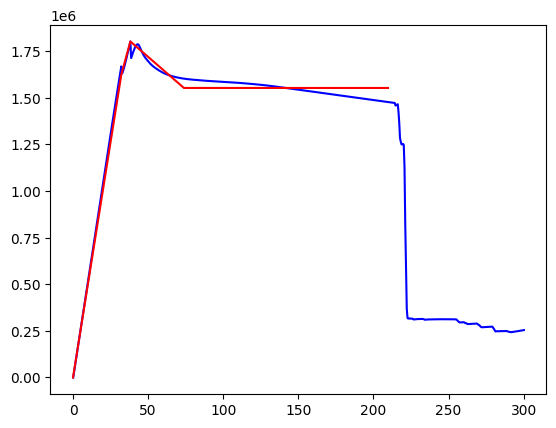

In [4]:
po = np.loadtxt(pushover_results_folder / "po_curve.csv", delimiter=",")
cut_idx = np.where(po[:,0] >=210)[0][0]
bb = fit_piecewise_backbone(po[:cut_idx, :])
fig, ax = plt.subplots()
ax.plot(po[:, 0], po[:, 1], color="b", label="MDOF")
ax.plot(bb[:, 0], bb[:, 1], color="r", label="Fit")


In [5]:
def _calculate_participation_factor(mass_matrix, modeshape_matrix, influence_matrix, node_info, dof):

    unconstrained_node_info = sorted([n for n in node_info if n[2] >= 0], key=lambda x: x[2])

    r1 = influence_matrix[:, 0]  # influence vector for the first mode
    idx_influence = np.where(r1 == 1)[0]  # indices of the dofs that have mass in the x direction

    # calculate the required parameters
    phi_1 = modeshape_matrix[:, 0] #/ np.max(Phi[:, 0])  # first mode shape

    aa = sorted([unconstrained_node_info[ii] for ii in idx_influence], key=lambda x: x[0]) # sort by node tag
    node_tags_used = np.reshape([a[0] for a in aa], (-1, 4), order="F")  # node tags for the dofs that have mass in the x direction, reshaped to have 4 columns (one for each column line)
    idxs = np.reshape([a[2] for a in aa], (-1, 4), order="F")  # indexes for the dofs that have mass in the x direction, reshaped to have 4 columns (one for each column line)

    phi = phi_1[idxs]#.mean(axis=1).reshape(-1, 1)
    norm_idx = np.abs(phi[-1, :]).argmax()
    normalisation_factor = phi[-1, norm_idx]
    phi /= normalisation_factor
    phi = phi.reshape(-1, 1)      # get it in a column vector

    m_vals = np.diagonal(mass_matrix)[idxs]
    m = np.zeros((len(phi), len(phi)))
    np.fill_diagonal(m, m_vals)     # get it in a diagonal matrix
    
    r = np.ones(phi.shape)

    generalised_mass = (phi.T @ m @ phi)[0, 0]
    m_star = (phi.T @ m @ r)[0, 0]     # from Fajfar (2000) and Baltzopoulos et al. 2018
    effective_mass = ((r.T @ m @ phi @ phi.T @ m @ r) / (phi.T @ m @ phi))[0, 0]
    Gamma = m_star / generalised_mass
    return Gamma, m, phi, node_tags_used, m_star, generalised_mass, effective_mass

    

In [6]:
# calculate the equivalent SDOF curve from the multilinear pushover curve

# load mass matrix and the modeshapes
with open(modal_results_folder / "modal_properties.json", "r") as file:
    modal_props = json.load(file)

M = np.loadtxt(modal_results_folder / "mass_matrix.csv", delimiter=",")
Phi = np.loadtxt(modal_results_folder / "mode_shapes.csv", delimiter=",")
influence_matrix = np.loadtxt(modal_results_folder / "influence_matrix.csv", delimiter=",")
node_info = json.load(open(modal_results_folder / "node_info.json", "r"))

Gamma, m, phi, node_tags_used, m_star, generalised_mass, effective_mass = _calculate_participation_factor(M, Phi, influence_matrix, node_info, dof=1)
print(f"participation factor: {Gamma}")
print(f"m* = {m_star:.2f}")
print(f"generalised modal mass = {generalised_mass:.2f}")
print(f"effective mass = {effective_mass:.2f}")


participation factor: 1.315085718788654
m* = 199.69
generalised modal mass = 151.85
effective mass = 262.62


SDOF Backbone:
[[0.00000000e+00 0.00000000e+00]
 [2.44509899e+01 1.23403733e+06]
 [2.90438464e+01 1.36927559e+06]
 [5.61568728e+01 1.17986423e+06]
 [1.59453597e+02 1.17986423e+06]]


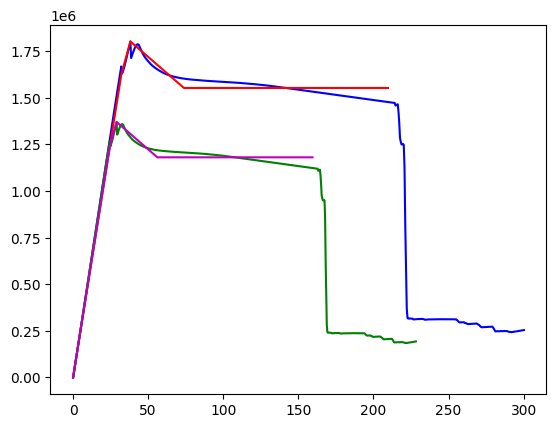

In [7]:
sdof_po = po / Gamma
sdof_bb = bb / Gamma

fig, ax = plt.subplots()
ax.plot(po[:, 0], po[:, 1], color="b", label="MDOF - True")
ax.plot(bb[:, 0], bb[:, 1], color="r", label="MDOF - PW")
ax.plot(sdof_po[:, 0], sdof_po[:, 1], color="g", label="Eq. SDOF - True")
ax.plot(sdof_bb[:, 0], sdof_bb[:, 1], color="m", label="Eq. SDOF - PW")

print("SDOF Backbone:")
print(sdof_bb)

## Compare SDOF Model Response

In [8]:
sdof_po_file = Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_sdof\pushover_umax_disp_200\po_curve.csv")
sdof_model_po = np.loadtxt(sdof_po_file, delimiter=",")

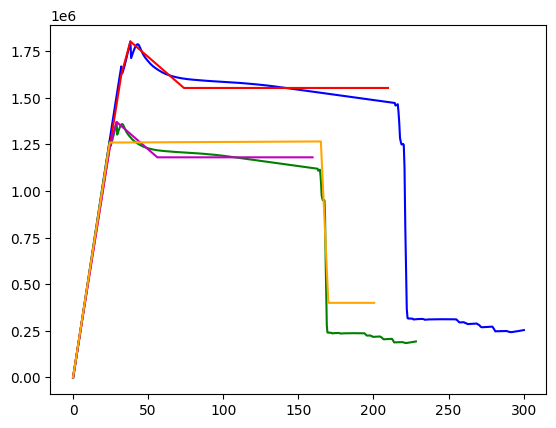

In [9]:
sdof_po = po / Gamma
sdof_bb = bb / Gamma

po = np.loadtxt(pushover_results_folder / "po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(po[:, 0], po[:, 1], color="b", label="MDOF - True")
ax.plot(bb[:, 0], bb[:, 1], color="r", label="MDOF - PW")
ax.plot(sdof_po[:, 0], sdof_po[:, 1], color="g", label="Eq. SDOF - True")
ax.plot(sdof_bb[:, 0], sdof_bb[:, 1], color="m", label="Eq. SDOF - PW")
ax.plot(sdof_model_po[:, 0], sdof_model_po[:, 1], color = "orange", label="SDOF_model")

## Plot the time history responses

### Record 1: FEMA P695 120121 - scale factor 2.0

In [10]:
# get the response of the MDOF system
with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\nltha_120121_sf2000\recorders.pickle"), "rb") as file:
    mdof_recorders = pickle.load(file)

with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\nltha_120121_sf2000\timearray.pickle"), "rb") as file:
    mdof_time = pickle.load(file)

roof_disp = get_recorder(mdof_recorders, "node_displacement", 101010400)
base_shear = get_recorder(mdof_recorders, "storey_shear", 1, 1)

# MDOF response converted to SDOF coordinates by dividing by the participation factor
Vb_mdof = base_shear.record[1] / Gamma / -1000        # equivalent SDOF base shear of MDOF system in kN
Ur_mdof = roof_disp.record[1] / Gamma                # eq. SDOF displacement of MDOF

In [11]:
# get the response of the SDOF system
with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_sdof\nltha_120121_sf2000\recorders.pickle"), "rb") as file:
    sdof_recorders = pickle.load(file)

with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_sdof\nltha_120121_sf2000\timearray.pickle"), "rb") as file:
    sdof_time = pickle.load(file)

disp = get_recorder(sdof_recorders, "node_displacement", 2)
force = get_recorder(sdof_recorders, "zerolength_force", 1)

Vb_sdof = np.array(force.record[1]) / 1000
U_sdof = np.array(disp.record[1])

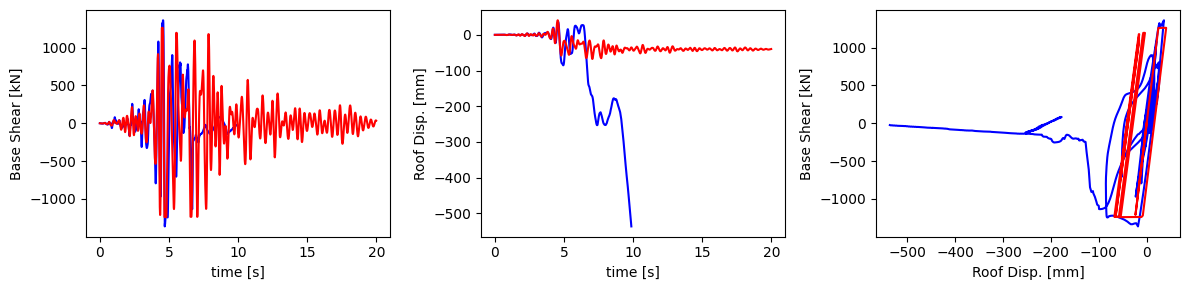

In [12]:
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 3))


ax1.plot(mdof_time, Vb_mdof, color="b")
ax1.plot(sdof_time, Vb_sdof, color="r")

ax2.plot(mdof_time, Ur_mdof, color="b")
ax2.plot(sdof_time, U_sdof, color="r")

ax3.plot(Ur_mdof, Vb_mdof, color="b")
ax3.plot(U_sdof, Vb_sdof, color="r")

ax1.set_xlabel("time [s]")
ax1.set_ylabel("Base Shear [kN]")
ax2.set_xlabel("time [s]")
ax2.set_ylabel("Roof Disp. [mm]")
ax3.set_xlabel("Roof Disp. [mm]")
ax3.set_ylabel("Base Shear [kN]")

plt.tight_layout()

## Soft Storey Pushover Response

# 2-Spring SODF Model

### Complete MDOF Model

Text(0, 0.5, 'Force [N]')

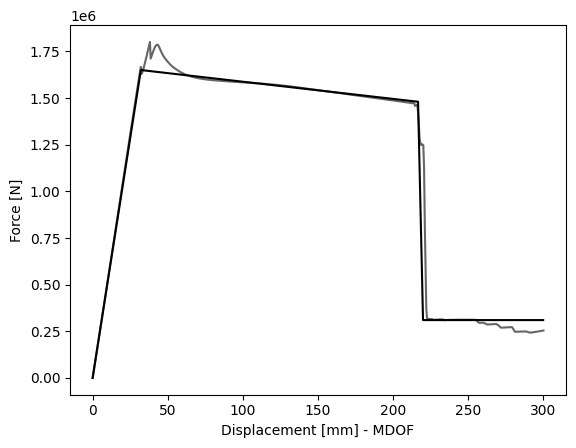

In [13]:
mdof_po = np.loadtxt(pushover_results_folder / "po_curve.csv", delimiter=",")

# hand picked backbone
mdof_bb = np.array([
    [0, 0],
    [32.155, 1650000],
    [216.7, 1480000],
    [220, 310000],
    [300, 310000]])

fig, ax = plt.subplots()
ax.plot(mdof_po[:, 0], mdof_po[:, 1], color="0.4", label="MDOF")
ax.plot(mdof_bb[:, 0], mdof_bb[:, 1], color="k", label="Mod Fit")
ax.set_xlabel("Displacement [mm] - MDOF")
ax.set_ylabel("Force [N]")


In [14]:
# calculate the equivalent SDOF curve from the multilinear pushover curve
# load mass matrix and the modeshapes
results_folder = Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\modal")
with open(results_folder / "modal_properties.json", "r") as file:
    modal_props = json.load(file)

M = np.loadtxt(results_folder / "mass_matrix.csv", delimiter=",")
Phi = np.loadtxt(results_folder / "mode_shapes.csv", delimiter=",")
influence_matrix = np.loadtxt(results_folder / "influence_matrix.csv", delimiter=",")
node_info = json.load(open(results_folder / "node_info.json", "r"))

Gamma_full, m, phi, node_tags_used, m_star, generalised_mass, effective_mass = _calculate_participation_factor(M, Phi, influence_matrix, node_info, dof=1)
print(f"participation factor: {Gamma_full}")
print(f"m* = {m_star:.2f}")
print(f"generalised modal mass = {generalised_mass:.2f}")
print(f"effective mass = {effective_mass:.2f}")

participation factor: 1.315085718788654
m* = 199.69
generalised modal mass = 151.85
effective mass = 262.62


In [15]:
# Eq. SDOF bb for the original system
sdof_po = mdof_po / Gamma_full
sdof_bb = mdof_bb / Gamma_full

## Frame Soft Storey Model

#### MODF SPO and Piecewise linear fit

MDOF Piecewise Backbone
[[0.00000000e+00 0.00000000e+00]
 [8.10489583e+01 1.54639233e+05]
 [1.00998958e+02 1.61511402e+05]
 [3.04698958e+02 0.00000000e+00]]


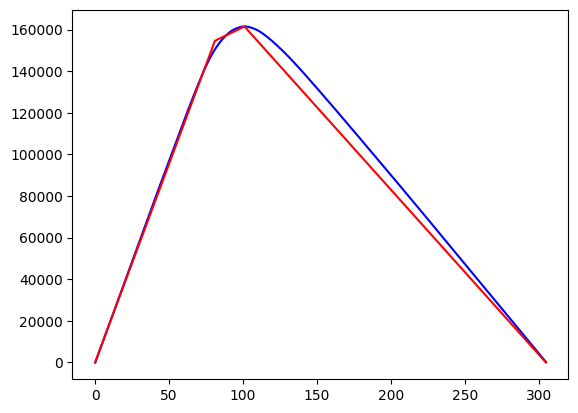

In [16]:
mdof_ss_po = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_softstorey\pushover\po_curve.csv", delimiter=",")

mdof_ss_bb = fit_piecewise_backbone(mdof_ss_po)

# match the final points
mdof_ss_bb[-1, :] = [mdof_ss_po[-1, 0], 0]

fig, ax = plt.subplots()
ax.plot(mdof_ss_po[:, 0], mdof_ss_po[:, 1], color="b", label="MDOF")
ax.plot(mdof_ss_bb[:, 0], mdof_ss_bb[:, 1], color="r", label="Fit")

print("MDOF Piecewise Backbone")
print(mdof_ss_bb)

#### Equivalent SDOF System

In [52]:
# calculate the equivalent SDOF curve from the multilinear pushover curve
# load mass matrix and the modeshapes
results_folder = Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_softstorey\modal")
with open(results_folder / "modal_properties.json", "r") as file:
    modal_props = json.load(file)

M = np.loadtxt(results_folder / "mass_matrix.csv", delimiter=",")
Phi = np.loadtxt(results_folder / "mode_shapes.csv", delimiter=",")
influence_matrix = np.loadtxt(results_folder / "influence_matrix.csv", delimiter=",")
node_info = json.load(open(results_folder / "node_info.json", "r"))

Gamma_ss, m, phi, node_tags_used, m_star, generalised_mass, effective_mass = _calculate_participation_factor(M, Phi, influence_matrix, node_info, dof=1)
print(f"participation factor: {Gamma_ss}")
print(f"m* = {m_star:.2f}")
print(f"generalised modal mass = {generalised_mass:.2f}")
print(f"effective mass = {effective_mass:.2f}")

participation factor: 1.0130873918771306
m* = 308.02
generalised modal mass = 304.04
effective mass = 312.05


In [18]:
sdof_ss_po = mdof_ss_po / Gamma_ss

## System Components

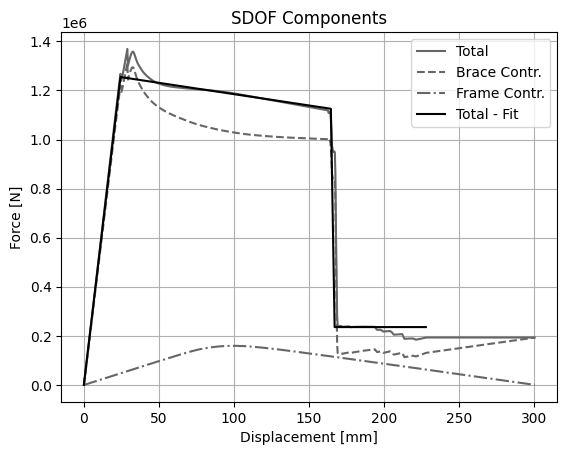

In [19]:
# plot the total, frame and brace pushovers together
x1 = sdof_po[:, 0]
x2 = sdof_ss_po[:, 0]

xs = np.append(x2, x1)
xs = sorted(np.array(list(set(xs))))
total = np.interp(xs, x1, sdof_po[:, 1])
frame = np.interp(xs, x2, sdof_ss_po[:, 1])
brace = total - frame

fig, ax = plt.subplots()
ax.plot(xs, total, "0.4", label="Total")
ax.plot(xs, brace, "0.4", ls="--", label="Brace Contr.")
ax.plot(xs, frame, "0.4", ls="-.", label="Frame Contr.")
ax.plot(sdof_bb[:, 0], sdof_bb[:, 1], color="k", label="Total - Fit")
ax.grid()
ax.set_title("SDOF Components")
ax.set_xlabel("Displacement [mm]")
ax.set_ylabel("Force [N]")
ax.legend()


## Fit A

Bilinear frame component with +ve and -ve slope

### Frame

In [20]:
# adjust the piecewise linear fit determined in the cells above so that it just
# has an ascending and a descending branch
K_up = mdof_ss_bb[1, 1] / mdof_ss_bb[1, 0]
K_dwn = (mdof_ss_bb[3, 1] - mdof_ss_bb[2, 1]) / (mdof_ss_bb[3, 0] - mdof_ss_bb[2, 0])
cd = -K_dwn * mdof_ss_bb[3, 0]
x = cd / (K_up - K_dwn)
y = K_up * x

fitA_frame_bb = np.array([[0, 0], [x, y], [mdof_ss_bb[3, 0], mdof_ss_bb[3, 1]]]) / Gamma_ss

print("Frame SDOF Backbone:")
print(fitA_frame_bb)

sdof_ss_Ke = K_up

Frame SDOF Backbone:
[[0.00000000e+00 0.00000000e+00]
 [8.82945450e+01 1.68463618e+05]
 [3.00762758e+02 0.00000000e+00]]


### Braces

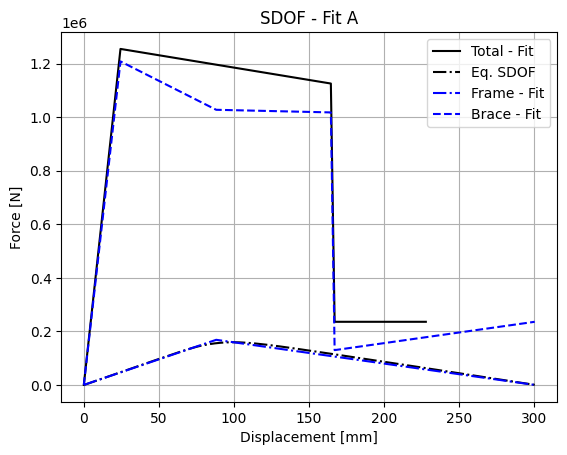

In [21]:
new_xs = sorted(np.append(sdof_bb[:, 0], fitA_frame_bb[:, 0]))

A_frame = np.column_stack([new_xs, np.interp(new_xs, fitA_frame_bb[:, 0], fitA_frame_bb[:, 1])])
A_total = np.column_stack([new_xs, np.interp(new_xs, sdof_bb[:, 0], sdof_bb[:, 1])])
A_brace = np.column_stack([new_xs, A_total[:, 1] - A_frame[:, 1]])

fig, ax = plt.subplots()
ax.plot(sdof_bb[:, 0], sdof_bb[:, 1], color="k", label="Total - Fit")
ax.plot(sdof_ss_po[:, 0], sdof_ss_po[:, 1], color="k", ls="-.", label="Eq. SDOF")
ax.plot(fitA_frame_bb[:, 0], fitA_frame_bb[:, 1], color="b", ls="-.", label="Frame - Fit")
ax.plot(A_brace[:, 0], A_brace[:, 1], color="b", ls="--", label="Brace - Fit")
ax.grid()
ax.set_title("SDOF - Fit A")
ax.set_xlabel("Displacement [mm]")
ax.set_ylabel("Force [N]")
ax.legend()

## Fit B

Another option is instead of matching the the hystersis from the frame with the soft storey like Nafeh et al. we can make up a an artificial one so that the total backbone curve is divided into two nice parts. This fit assumes that the yield point of the frame SDOF is at the point where the residual strength starts. This is similar to Approach 2 described by Nafeh et al. (2020). We could add bit of a negative slope afterwards as well if needed

In [22]:
fitB_frame_bb = np.array([[0, 0],
                          [sdof_bb[-2, 0], sdof_bb[-2, 1]],
                          [sdof_ss_po[-1, 0], sdof_bb[-1, 1] * 0.99]])

print("Frame SDOF Backbone:")
print(fitB_frame_bb)

Frame SDOF Backbone:
[[0.00000000e+00 0.00000000e+00]
 [1.67289475e+02 2.35726079e+05]
 [3.00762758e+02 2.33368818e+05]]


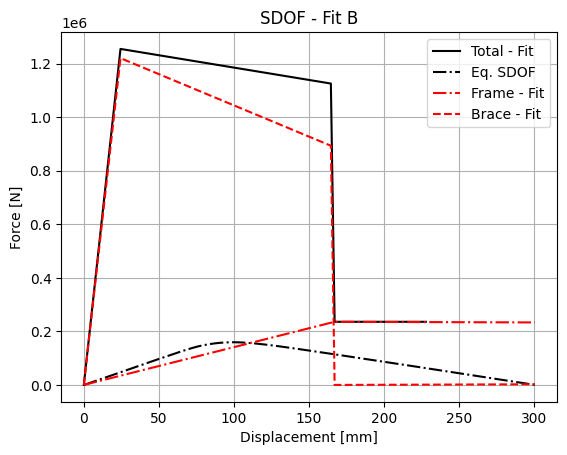

In [23]:
new_xs = sorted(np.append(sdof_bb[:, 0], fitB_frame_bb[:, 0]))

B_frame = np.column_stack([new_xs, np.interp(new_xs, fitB_frame_bb[:, 0], fitB_frame_bb[:, 1])])
B_total = np.column_stack([new_xs, np.interp(new_xs, sdof_bb[:, 0], sdof_bb[:, 1])])
B_brace = np.column_stack([new_xs, B_total[:, 1] - B_frame[:, 1]])

fig, ax = plt.subplots()
ax.plot(sdof_bb[:, 0], sdof_bb[:, 1], color="k", label="Total - Fit")
ax.plot(sdof_ss_po[:, 0], sdof_ss_po[:, 1], color="k", ls="-.", label="Eq. SDOF")
ax.plot(fitB_frame_bb[:, 0], fitB_frame_bb[:, 1], color="r", ls="-.", label="Frame - Fit")
ax.plot(B_brace[:, 0], B_brace[:, 1], color="r", ls="--", label="Brace - Fit")
ax.grid()
ax.set_title("SDOF - Fit B")
ax.set_xlabel("Displacement [mm]")
ax.set_ylabel("Force [N]")
ax.legend()

## Fit C

This approach is a mix of A and B. It uses the same period as Fit A but matches the yield plateau to the final section of the total pushover curve as in Fit B

In [24]:
fu = sdof_bb[-1, 1] / 1.001     
fy = fu / 1.001                 # just to stop a flat line

fitC_frame_bb = np.array([[0, 0],
                               [fy / sdof_ss_Ke, fy],
                               [sdof_ss_po[-1, 0], fu]])

print("Frame SDOF Backbone:")
print(fitC_frame_bb)

Frame SDOF Backbone:
[[0.00000000e+00 0.00000000e+00]
 [1.23301178e+02 2.35255333e+05]
 [3.00762758e+02 2.35490588e+05]]


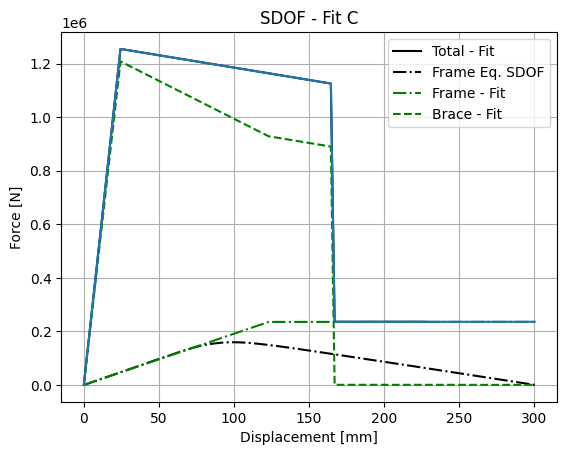

In [43]:
new_xs = sorted(np.append(sdof_bb[:, 0], fitC_frame_bb[:, 0]))

C_frame = np.column_stack([new_xs, np.interp(new_xs, fitC_frame_bb[:, 0], fitC_frame_bb[:, 1])])
C_total = np.column_stack([new_xs, np.interp(new_xs, sdof_bb[:, 0], sdof_bb[:, 1])])
C_brace = np.column_stack([new_xs, C_total[:, 1] - C_frame[:, 1]])

fig, ax = plt.subplots()
ax.plot(sdof_bb[:, 0], sdof_bb[:, 1], color="k", label="Total - Fit")
ax.plot(sdof_ss_po[:, 0], sdof_ss_po[:, 1], color="k", ls="-.", label="Frame Eq. SDOF")
ax.plot(fitC_frame_bb[:, 0], fitC_frame_bb[:, 1], color="green", ls="-.", label="Frame - Fit")
ax.plot(C_brace[:, 0], C_brace[:, 1], color="green", ls="--", label="Brace - Fit")
# ax.plot(new_xs, C_brace[:, 1] + C_frame[:,1])
ax.grid()
ax.set_title("SDOF - Fit C")
ax.set_xlabel("Displacement [mm]")
ax.set_ylabel("Force [N]")
ax.legend()

## Comparison

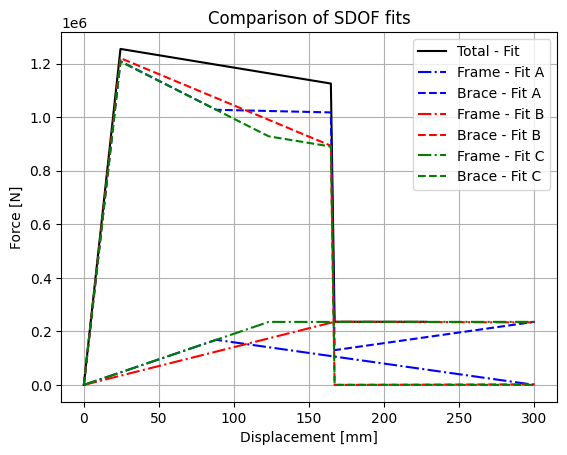

In [26]:
fig, ax = plt.subplots()

ax.plot(sdof_bb[:, 0], sdof_bb[:, 1], color="k", label="Total - Fit")

ax.plot(fitA_frame_bb[:, 0], fitA_frame_bb[:, 1], color="b", ls="-.", label="Frame - Fit A")
ax.plot(A_brace[:, 0], A_brace[:, 1], color="b", ls="--", label="Brace - Fit A")

ax.plot(fitB_frame_bb[:, 0], fitB_frame_bb[:, 1], color="r", ls="-.", label="Frame - Fit B")
ax.plot(B_brace[:, 0], B_brace[:, 1], color="r", ls="--", label="Brace - Fit B")

ax.plot(fitC_frame_bb[:, 0], fitC_frame_bb[:, 1], color="g", ls="-.", label="Frame - Fit C")
ax.plot(C_brace[:, 0], C_brace[:, 1], color="g", ls="--", label="Brace - Fit C")
ax.grid()
ax.set_title("Comparison of SDOF fits")
ax.set_xlabel("Displacement [mm]")
ax.set_ylabel("Force [N]")
ax.legend()

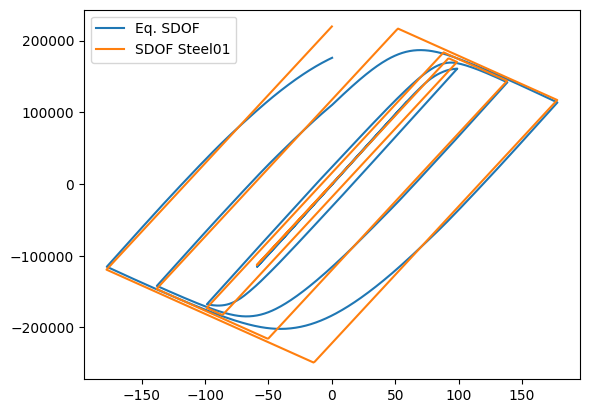

In [27]:
mdof_ss_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_softstorey\cyclic_pushover\po_curve.csv", delimiter=",")
sdof_ss_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_softstorey_sdof\cyclic_pushover\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(mdof_ss_cpo[:, 0] / Gamma_ss, mdof_ss_cpo[:, 1] / Gamma_ss, label = "Eq. SDOF")
ax.plot(sdof_ss_cpo[:, 0], sdof_ss_cpo[:, 1], label = "SDOF Steel01")
ax.legend()

## Testing Fits

### SSE Objective Function

The objective function for this work is based on the one proposed by Karamanci et al. It is the square root of the sum of the squared error between the force of the mdof system and the  sdof system for a given displacment

In [50]:
def cumulative_distance(d):
    """
    Calculates cumulative absolute displacement.
    i.e. the total distance the roof node travelled
    """
    return np.concatenate(([0], np.cumsum(np.abs(np.diff(d)))))


def normalised_path(d):
    # Calculate incremental absolute travel
    diffs = np.abs(np.diff(d))
    # Cumulative travel
    path = np.concatenate(([0], np.cumsum(diffs)))
    # Normalize to [0, 1]
    return path / path[-1]


def objective_func(exp_response, sim_response):
    return np.sqrt(np.sum((exp_response - sim_response) ** 2))



### Fit B

In [28]:
## Fit B Points - SDOF
print("Fit B - Material 1 - Frame")
print(fitB_frame_bb)

fitB_brace_bb = B_brace[[0, 2, 3, 4]]
print("\nFit B - Material 2 - Braces")
print(fitB_brace_bb)

Fit B - Material 1 - Frame
[[0.00000000e+00 0.00000000e+00]
 [1.67289475e+02 2.35726079e+05]
 [3.00762758e+02 2.33368818e+05]]

Fit B - Material 2 - Braces
[[0.00000000e+00 0.00000000e+00]
 [2.44508776e+01 1.22021756e+06]
 [1.64780133e+02 8.93211738e+05]
 [1.67289475e+02 0.00000000e+00]]


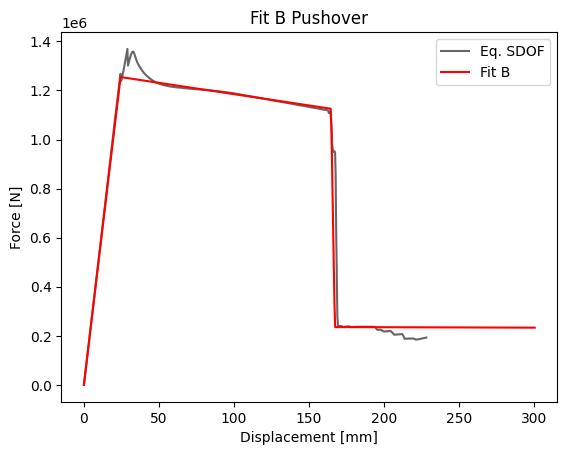

In [29]:
sdof_fit3_po = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\pushover\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(sdof_po[:, 0], sdof_po[:, 1], color="0.4", label="Eq. SDOF")
ax.plot(sdof_fit3_po[:, 0], sdof_fit3_po[:, 1], color="r", label="Fit B")
ax.set_title("Fit B Pushover")
ax.set_xlabel("Displacement [mm]")
ax.set_ylabel("Force [N]")
ax.legend()


#### Test 1

MDOF total travel 1155.9247628210287
SDOF total travel 1155.959999999991
MDOF n path pts 3295
SDOF n path pts 2793


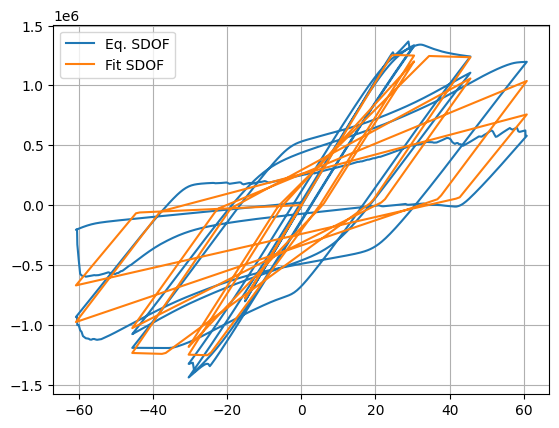

In [31]:
t1_sdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\cyclic_pushover\po_curve.csv", delimiter=",")
t1_mdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\cyclic_pushover\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(t1_mdof_cpo[:, 0] / Gamma_full, t1_mdof_cpo[:, 1] / Gamma_full, label="Eq. SDOF")
ax.plot(t1_sdof_cpo[:, 0], t1_sdof_cpo[:, 1], label="Fit SDOF")
ax.legend()

print("MDOF total travel", cumulative_distance(t1_mdof_cpo[:, 0])[-1] / Gamma_full)
print("SDOF total travel", cumulative_distance(t1_sdof_cpo[:, 0])[-1] )
print("MDOF n path pts", len(normalised_path(t1_mdof_cpo[:, 0] / Gamma_full)))
print("SDOF n path pts", len(normalised_path(t1_sdof_cpo[:, 0])))

ax.grid()

22110446.540696908


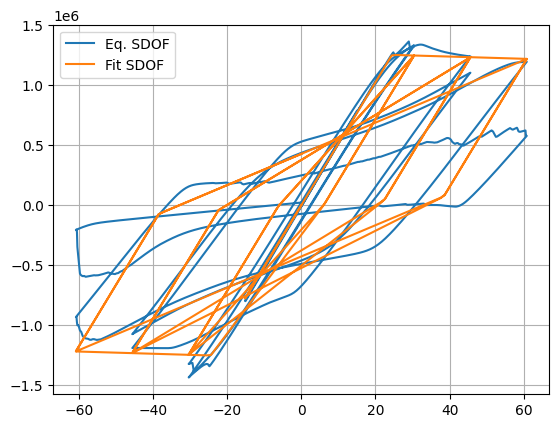

In [51]:
xi_exp = normalised_path(t1_mdof_cpo[:, 0])
xi_sim = normalised_path(t1_sdof_cpo[:, 0])
xi_ref = np.linspace(0, 1, 10000)
    
# 3. Interpolate both to the [0, 1] reference
# This aligns the sequence of the cycles and reduces the error of the overshoot / undershoot in the pushover
f_mdof = np.interp(xi_ref, xi_exp, t1_mdof_cpo[:, 1] / Gamma_full)
f_sdof = np.interp(xi_ref, xi_sim, t1_sdof_cpo[:, 1])

# create a SDOF displacement vector for plotting
d_sdof = np.interp(xi_ref, xi_sim, t1_sdof_cpo[:, 0]) 

fig, ax = plt.subplots()
ax.plot(d_sdof, f_mdof, label="Eq. SDOF")
ax.plot(d_sdof, f_sdof, label="Fit SDOF")
ax.grid()
ax.legend()

# calculate the objective function
score = objective_func(f_mdof, f_sdof)
print(score)


#### Test 2

mdof_distance 1346.0264394100257
sdof_distance 2190.11999999996


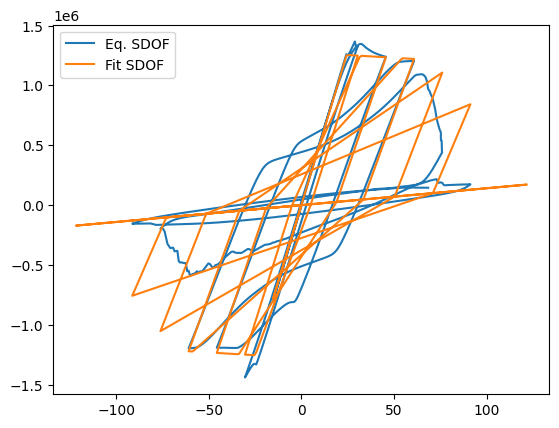

In [33]:
t2_sdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\cyclic_pushover_2\po_curve.csv", delimiter=",")
t2_mdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\cyclic_pushover_2\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(t2_mdof_cpo[:, 0] / Gamma_full, t2_mdof_cpo[:, 1] / Gamma_full, label="Eq. SDOF")
ax.plot(t2_sdof_cpo[:, 0], t2_sdof_cpo[:, 1], label="Fit SDOF")
ax.legend()

print("mdof_distance", cumulative_distance(t2_mdof_cpo[:, 0] / Gamma_full)[-1])
print("sdof_distance", cumulative_distance(t2_sdof_cpo[:, 0])[-1])

#### Test 3

mdof_distance 1095.0922263125508
sdof_distance 1095.1200000000144


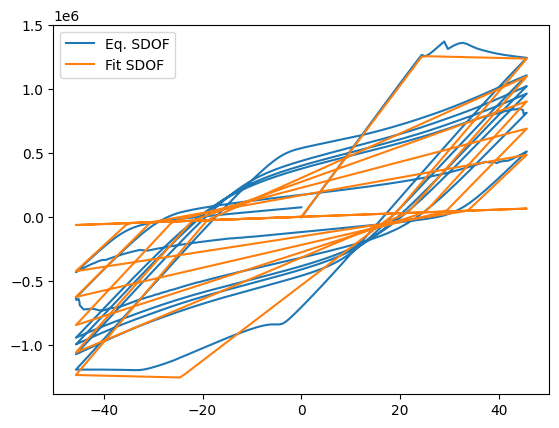

In [34]:
t3_sdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\cyclic_pushover_3\po_curve.csv", delimiter=",")
t3_mdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\cyclic_pushover_3\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(t3_mdof_cpo[:, 0] / Gamma_full, t3_mdof_cpo[:, 1] / Gamma_full, label="Eq. SDOF")
ax.plot(t3_sdof_cpo[:, 0], t3_sdof_cpo[:, 1], label="Fit SDOF")
ax.legend()

print("mdof_distance", cumulative_distance(t3_mdof_cpo[:, 0] / Gamma_full)[-1])
print("sdof_distance", cumulative_distance(t3_sdof_cpo[:, 0])[-1])

#### NLTHA 121021

(-100.0, 50.0)

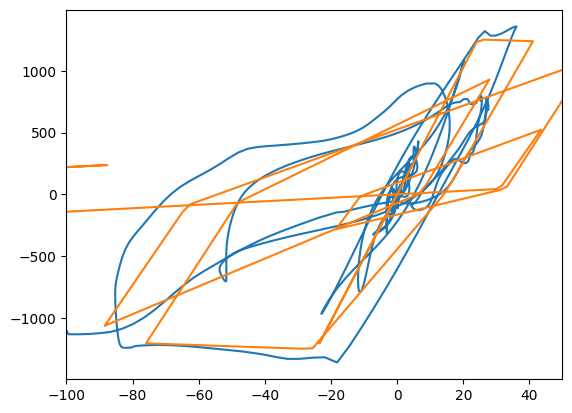

In [54]:
# get the response of the MDOF system
with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\nltha_120121_sf2000\recorders.pickle"), "rb") as file:
    mdof_recorders = pickle.load(file)

with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\nltha_120121_sf2000\timearray.pickle"), "rb") as file:
    mdof_time = pickle.load(file)

roof_disp = get_recorder(mdof_recorders, "node_displacement", 101010400)
base_shear = get_recorder(mdof_recorders, "storey_shear", 1, 1)

# MDOF response converted to SDOF coordinates by dividing by the participation factor
Vb_mdof_1 = base_shear.record[1] / Gamma_full / -1000        # equivalent SDOF base shear of MDOF system in kN
Ur_mdof_1 = roof_disp.record[1] / Gamma_full                # eq. SDOF displacement of MDOF

# get the response of the SDOF system
with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\nltha_120121_sf2000\recorders.pickle"), "rb") as file:
    sdof_recorders = pickle.load(file)

with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\nltha_120121_sf2000\timearray.pickle"), "rb") as file:
    sdof_time = pickle.load(file)

disp = get_recorder(sdof_recorders, "node_displacement", 2)
force_ele1 = get_recorder(sdof_recorders, "zerolength_force", 1)
force_ele2 = get_recorder(sdof_recorders, "zerolength_force", 2)

Vb_sdof_1 = (np.array(force_ele1.record[1]) + np.array(force_ele2.record[1])) / 1000
U_sdof_1 = np.array(disp.record[1])

fig, ax = plt.subplots()
ax.plot(Ur_mdof_1, Vb_mdof_1, label="Eq. SDOF")
ax.plot(U_sdof_1, Vb_sdof_1, label="Fit SDOF")
ax.set_xlim(-100, 50)

#### NLTHA 120621

(-100.0, 100.0)

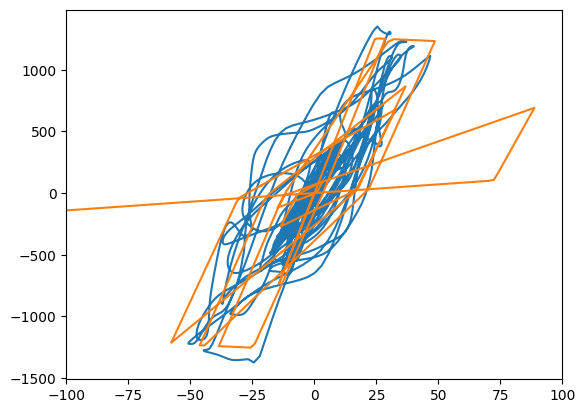

In [36]:
# get the response of the MDOF system
with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\nltha_120621_sf2600\recorders.pickle"), "rb") as file:
    mdof_recorders = pickle.load(file)

with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\nltha_120621_sf2600\timearray.pickle"), "rb") as file:
    mdof_time = pickle.load(file)

roof_disp = get_recorder(mdof_recorders, "node_displacement", 101010400)
base_shear = get_recorder(mdof_recorders, "storey_shear", 1, 1)

# MDOF response converted to SDOF coordinates by dividing by the participation factor
Vb_mdof_1 = base_shear.record[1] / Gamma_full / -1000        # equivalent SDOF base shear of MDOF system in kN
Ur_mdof_1 = roof_disp.record[1] / Gamma_full                # eq. SDOF displacement of MDOF

# get the response of the SDOF system
with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\nltha_120621_sf2600\recorders.pickle"), "rb") as file:
    sdof_recorders = pickle.load(file)

with open(Path(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitB_sdof\nltha_120621_sf2600\timearray.pickle"), "rb") as file:
    sdof_time = pickle.load(file)

disp = get_recorder(sdof_recorders, "node_displacement", 2)
force_ele1 = get_recorder(sdof_recorders, "zerolength_force", 1)
force_ele2 = get_recorder(sdof_recorders, "zerolength_force", 2)

Vb_sdof_1 = (np.array(force_ele1.record[1]) + np.array(force_ele2.record[1])) / 1000
U_sdof_1 = np.array(disp.record[1])

fig, ax = plt.subplots()
ax.plot(Ur_mdof_1, Vb_mdof_1, label="Eq. SDOF")
ax.plot(U_sdof_1, Vb_sdof_1, label="Fit SDOF")
ax.set_xlim(-100, 100)

### Fit C

In [45]:
## Fit C Points - SDOF
print("Fit C - Material 1 - Frame")
print(fitC_frame_bb)

fitC_brace_bb = C_brace[1:6, :]
print("\nFit C - Material 2 - Braces")
print(fitC_brace_bb)

Fit C - Material 1 - Frame
[[0.00000000e+00 0.00000000e+00]
 [1.23301178e+02 2.35255333e+05]
 [3.00762758e+02 2.35490588e+05]]

Fit C - Material 2 - Braces
[[0.00000000e+00 0.00000000e+00]
 [2.44508776e+01 1.20801945e+06]
 [1.23301178e+02 9.28356364e+05]
 [1.64780133e+02 8.90091605e+05]
 [1.67289475e+02 4.12431995e+02]]


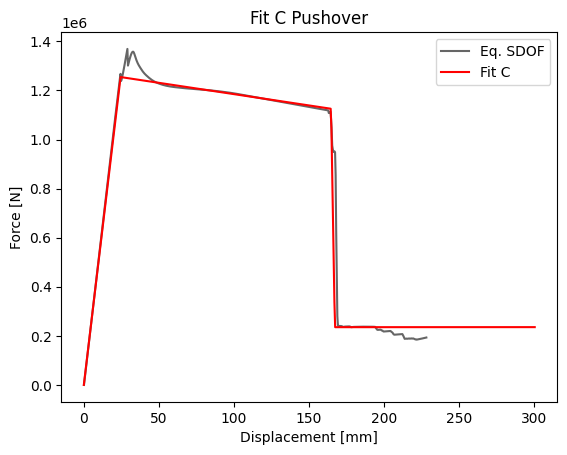

In [46]:
sdof_fitC_po = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitC_sdof\pushover\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(sdof_po[:, 0], sdof_po[:, 1], color="0.4", label="Eq. SDOF")
ax.plot(sdof_fitC_po[:, 0], sdof_fitC_po[:, 1], color="r", label="Fit C")
ax.set_title("Fit C Pushover")
ax.set_xlabel("Displacement [mm]")
ax.set_ylabel("Force [N]")
ax.legend()


#### Test 1

MDOF total travel 1155.9247628210287
SDOF total travel 1155.954045474652
MDOF n path pts 3295
SDOF n path pts 3960


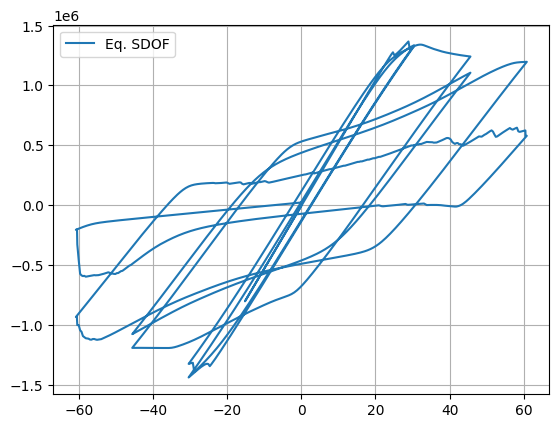

In [55]:
t1_sdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitC_sdof\cyclic_pushover\po_curve.csv", delimiter=",")
t1_mdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\cyclic_pushover\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(t1_mdof_cpo[:, 0] / Gamma_full, t1_mdof_cpo[:, 1] / Gamma_full, label="Eq. SDOF")
# ax.plot(t1_sdof_cpo[:, 0], t1_sdof_cpo[:, 1], label="Fit SDOF")
ax.legend()

print("MDOF total travel", cumulative_distance(t1_mdof_cpo[:, 0])[-1] / Gamma_full)
print("SDOF total travel", cumulative_distance(t1_sdof_cpo[:, 0])[-1] )
print("MDOF n path pts", len(normalised_path(t1_mdof_cpo[:, 0] / Gamma_full)))
print("SDOF n path pts", len(normalised_path(t1_sdof_cpo[:, 0])))

ax.grid()

#### Test 2

mdof_distance 1346.0264394100257
sdof_distance 2190.11999999996


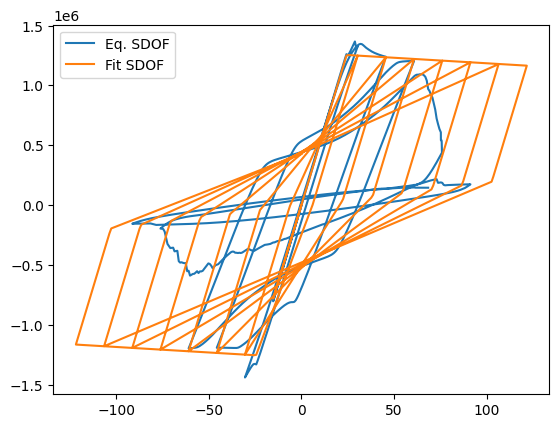

In [48]:
t2_sdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitC_sdof\cyclic_pushover_2\po_curve.csv", delimiter=",")
t2_mdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\cyclic_pushover_2\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(t2_mdof_cpo[:, 0] / Gamma_full, t2_mdof_cpo[:, 1] / Gamma_full, label="Eq. SDOF")
ax.plot(t2_sdof_cpo[:, 0], t2_sdof_cpo[:, 1], label="Fit SDOF")
ax.legend()

print("mdof_distance", cumulative_distance(t2_mdof_cpo[:, 0] / Gamma_full)[-1])
print("sdof_distance", cumulative_distance(t2_sdof_cpo[:, 0])[-1])

#### Test 3

mdof_distance 1095.0922263125508
sdof_distance 1095.110075791116


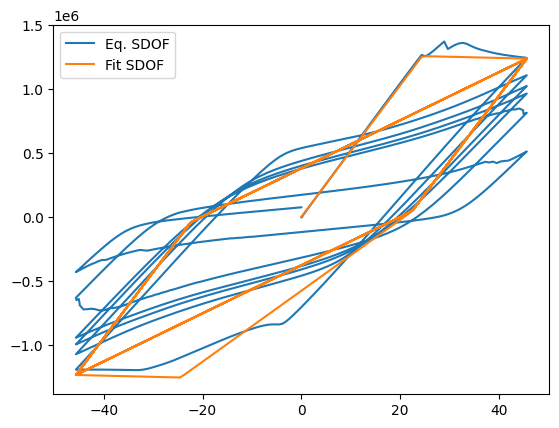

In [49]:
t3_sdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41_fitC_sdof\cyclic_pushover_3\po_curve.csv", delimiter=",")
t3_mdof_cpo = np.loadtxt(r"E:\02_wp1pt4pt1_po_analyses_for_sdof_fitting\3s_cbf_dc2_41\cyclic_pushover_3\po_curve.csv", delimiter=",")

fig, ax = plt.subplots()
ax.plot(t3_mdof_cpo[:, 0] / Gamma_full, t3_mdof_cpo[:, 1] / Gamma_full, label="Eq. SDOF")
ax.plot(t3_sdof_cpo[:, 0], t3_sdof_cpo[:, 1], label="Fit SDOF")
ax.legend()

print("mdof_distance", cumulative_distance(t3_mdof_cpo[:, 0] / Gamma_full)[-1])
print("sdof_distance", cumulative_distance(t3_sdof_cpo[:, 0])[-1])